# First Variational Autoencoder

In [1]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.model_selection import train_test_split
from keras import regularizers

import os
import sys

sys.path.append(os.path.abspath('..'))
from proyecto1_deep_learning.data_loader import load_data_3

In [2]:
# CONFIG
LATENT_DIM  = 2
EPOCHS      = 200
BATCH_SIZE  = 64
BETA        = 1     # KL weight (1 = standard VAE)
NEGATIVE_SLOPE = 0.2 # LeakyReLU negative slope

## Load the data

In [3]:
x_train, x_test = load_data_3()

image_shape = x_train.shape[1:]
print(f"Image shape: {image_shape}")

Image shape: (128, 128, 3)


In [4]:
x_train.shape, x_test.shape

((168, 128, 128, 3), (43, 128, 128, 3))

## Normalization

In [5]:
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

print(f'x_train min: {x_train.min()}, max: {x_train.max()}')
print(f'x_test min: {x_test.min()}, max: {x_test.max()}')

x_train min: 0.0, max: 1.0
x_test min: 0.0, max: 1.0


## Variational Autoencoder

In [20]:
L2          = 1e-4
DROPOUT     = 0.3

def build_encoder(image_shape, latent_dim):
    encoder_input = keras.Input(shape=image_shape, name='encoder_input')

    # 128 -> 64
    x = layers.Conv2D(32, 3, strides=2, padding='same', use_bias=False)(encoder_input)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # 64 -> 32
    x = layers.Conv2D(64, 3, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # 32 -> 16
    x = layers.Conv2D(128, 3, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(L2))(x)
    x = layers.Dropout(DROPOUT)(x)

    mu      = layers.Dense(latent_dim, name='mu')(x)
    log_var = layers.Dense(latent_dim, name='log_var')(x)
    z       = Sampling(name='z')([mu, log_var])

    encoder = keras.Model(encoder_input, [mu, log_var, z], name='encoder')
    encoder.summary()
    return encoder


def build_decoder(image_shape, latent_dim):
    decoder_input = keras.Input(shape=(latent_dim,), name='decoder_input')

    x = layers.Dense(16 * 16 * 128, activation='relu',
                     kernel_regularizer=regularizers.l2(L2))(decoder_input)
    x = layers.Reshape((16, 16, 128))(x)

    # 16 -> 32
    x = layers.Conv2DTranspose(128, 3, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=NEGATIVE_SLOPE)(x)

    # 32 -> 64
    x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=NEGATIVE_SLOPE)(x)

    # 64 -> 128
    x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=NEGATIVE_SLOPE)(x)

    decoder_output = layers.Conv2DTranspose(
        image_shape[2], 3,
        activation='sigmoid',
        padding='same',
        name='decoder_output'
    )(x)

    decoder = keras.Model(decoder_input, decoder_output, name='decoder')
    decoder.summary()
    return decoder


class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        z_log_var = tf.clip_by_value(z_log_var, -4.0, 4.0)
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    def get_config(self):
        return super().get_config()


class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=1.0):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.beta    = beta

        self.total_loss_tracker          = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker             = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def get_config(self):
        config = super().get_config()
        config.update({
            'encoder': keras.saving.serialize_keras_object(self.encoder),
            'decoder': keras.saving.serialize_keras_object(self.decoder),
            'beta':    self.beta,
        })
        return config

    @classmethod
    def from_config(cls, config):
        encoder = keras.saving.deserialize_keras_object(config.pop('encoder'))
        decoder = keras.saving.deserialize_keras_object(config.pop('decoder'))
        return cls(encoder=encoder, decoder=decoder, **config)

    def call(self, inputs):
        mu, log_var, z = self.encoder(inputs)
        return self.decoder(z)

    def _compute_losses(self, x):
        mu, log_var, z = self.encoder(x)
        log_var   = tf.clip_by_value(log_var, -4.0, 4.0)
        z_decoded = self.decoder(z)

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.square(x - z_decoded),
                axis=(1, 2, 3)
            )
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1.0 + log_var - tf.square(mu) - tf.exp(log_var),
                axis=1
            )
        )

        total_loss = reconstruction_loss + self.beta * kl_loss
        return total_loss, reconstruction_loss, kl_loss

    def train_step(self, data):
        x, _ = data
        with tf.GradientTape() as tape:
            total_loss, reconstruction_loss, kl_loss = self._compute_losses(x)

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, _ = data
        total_loss, reconstruction_loss, kl_loss = self._compute_losses(x)
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

In [21]:
encoder = build_encoder(image_shape, LATENT_DIM)
decoder = build_decoder(image_shape, LATENT_DIM)
vae = VAE(encoder, decoder, beta=BETA)

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │        864 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,432 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │     73,728 │ activation_4[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 32768)     │          0 │ activation_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │ 16,777,728 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 2)         │      1,026 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_var (Dense)     │ (None, 2)         │      1,026 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Sampling)        │ (None, 2)         │          0 │ mu[0][0],         │
│                     │                   │            │ log_var[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,873,700 (64.37 MB)

 Trainable params: 16,873,252 (64.37 MB)

 Non-trainable params: 448 (1.75 KB)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32768)          │        98,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 32, 32, 128)    │       147,456 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 64, 64, 64)     │        73,728 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 128, 128, 32)   │        18,432 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output                  │ (None, 128, 128, 3)    │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 339,683 (1.30 MB)

 Trainable params: 339,235 (1.29 MB)

 Non-trainable params: 448 (1.75 KB)

In [22]:
def train_vae(vae: VAE, x_train):
    vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_total_loss", 
            patience=25,
            restore_best_weights=True, 
            mode='min',
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_total_loss", 
            patience=5,
            factor=0.5, 
            min_lr=1e-6, 
            mode='min',
            verbose=1
        ),
    ]

    history = vae.fit(
        x_train, x_train,
        validation_split=0.1,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
    )
    return history

In [23]:
history = train_vae(vae, x_train)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 453ms/step - kl_loss: 7.0367 - reconstruction_loss: 9449.0420 - total_loss: 9456.0791 - val_kl_loss: 6.9215 - val_reconstruction_loss: 9671.4766 - val_total_loss: 9678.3984 - learning_rate: 0.0010
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - kl_loss: 4.7005 - reconstruction_loss: 9238.3789 - total_loss: 9243.0801 - val_kl_loss: 6.8383 - val_reconstruction_loss: 9446.1475 - val_total_loss: 9452.9854 - learning_rate: 0.0010
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - kl_loss: 30.1448 - reconstruction_loss: 8818.5557 - total_loss: 8848.7002 - val_kl_loss: 196.5186 - val_reconstruction_loss: 7537.6367 - val_total_loss: 7734.1553 - learning_rate: 0.0010
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - kl_loss: 706.4686 - reconstruction_loss: 5566.8589 - total_loss: 6273.3276 - val_kl_loss: 1481.5034 - val_reconstruction_loss: 3062.0828 - val_total_loss: 4543.5859 - learning_rate: 0.0010
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 170m

In [24]:
def plot_history(history: keras.callbacks.History,
                 save_path: str = "../reports/figures/training_history.png"):
    tracked = [
        ("total_loss",          "Total Loss"),
        ("reconstruction_loss", "Reconstruction Loss"),
        ("kl_loss",             "KL Loss"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("VAE Training History", fontsize=14)

    for ax, (key, title) in zip(axes, tracked):
        ax.plot(history.history[key],            label="Train")
        ax.plot(history.history[f"val_{key}"],   label="Validation")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"History plot saved to {save_path}")

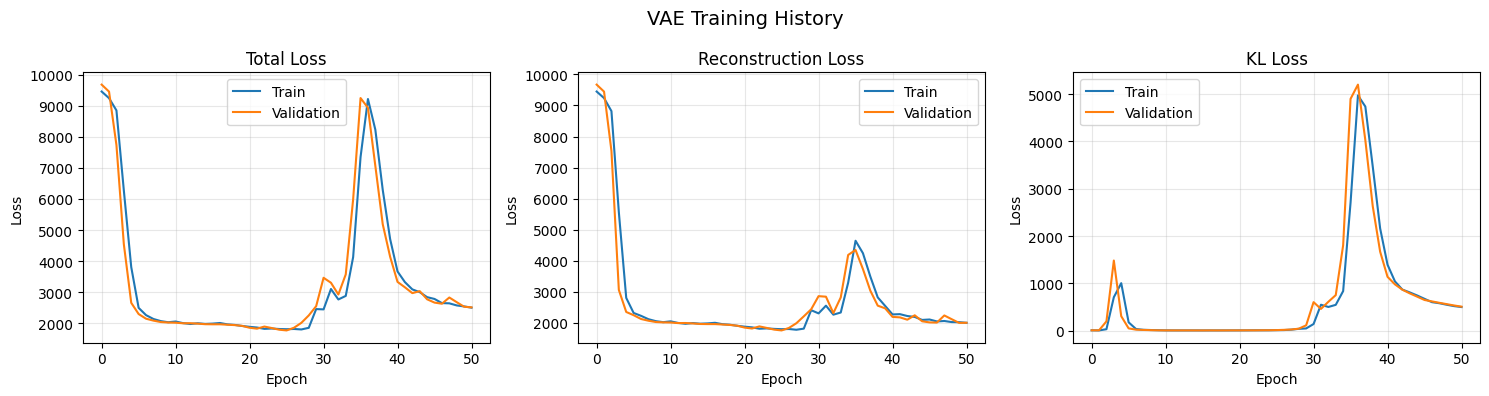

History plot saved to ../reports/figures/training_history.png


In [25]:
plot_history(history)

In [26]:
def evaluate_on_test(
    vae: VAE,
    decoder: keras.Model,
    x_test: np.ndarray,
    n_show: int = 5,
    save_path: str = "../reports/figures/test_reconstructions.png",
):
    print("\n── Test Set Evaluation ──")
    results = vae.evaluate(x_test, x_test, batch_size=BATCH_SIZE, verbose=1)
    print(f"  total_loss:          {results[0]:.4f}")
    print(f"  reconstruction_loss: {results[1]:.4f}")
    print(f"  kl_loss:             {results[2]:.4f}")

    # Reconstruct images
    n_show = min(n_show, len(x_test))
    samples = x_test[:n_show]
    mu, log_var, z = vae.encoder.predict(samples, verbose=0)
    reconstructed  = decoder.predict(z, verbose=0)

    fig, axes = plt.subplots(2, n_show, figsize=(n_show * 2.5, 5))
    fig.suptitle("Top: Original  |  Bottom: Reconstructed", fontsize=11)

    for i in range(n_show):
        axes[0, i].imshow(np.clip(samples[i], 0, 1))
        axes[0, i].axis("off")
        axes[1, i].imshow(np.clip(reconstructed[i], 0, 1))
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Reconstructions saved to {save_path}")


── Test Set Evaluation ──
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - kl_loss: 11.5082 - reconstruction_loss: 1766.5247 - total_loss: 1778.0328
  total_loss:          1778.0328
  reconstruction_loss: 1766.5247
  kl_loss:             11.5082


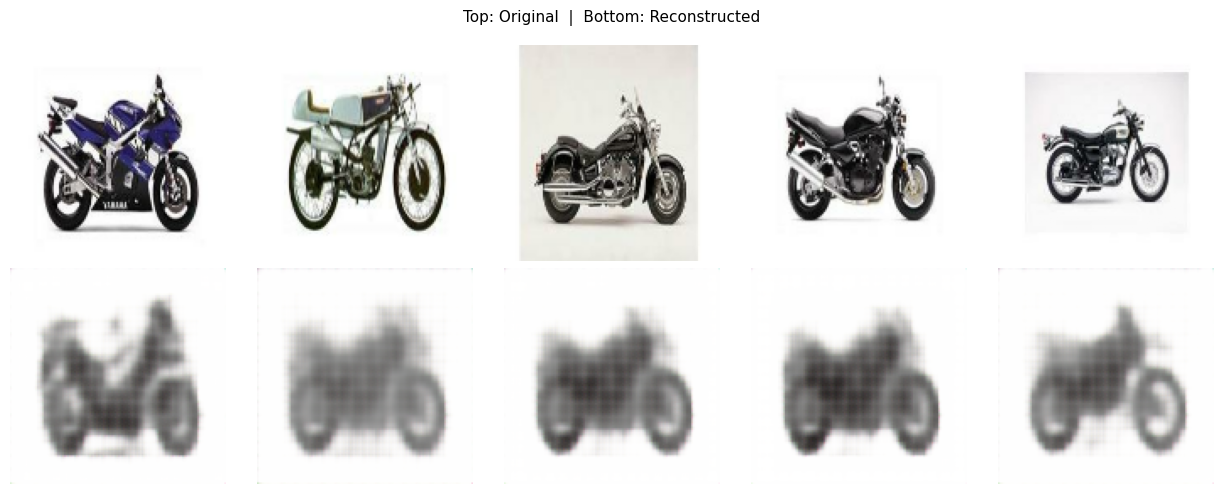

Reconstructions saved to ../reports/figures/test_reconstructions.png


In [27]:
evaluate_on_test(vae, decoder, x_test)

In [28]:
def generate_images(
    decoder: keras.Model,
    n_images: int,
) -> np.ndarray:
    """Sample n_images points from N(0, I) and decode them into images.

    Args:
        decoder:   The standalone decoder model.
        n_images:  How many images to generate.

    Returns:
        numpy array of shape (n_images, H, W, C) with pixel values in [0, 1].
    """
    z = np.random.normal(size=(n_images, LATENT_DIM)).astype("float32")
    generated = decoder.predict(z, verbose=0)
    return generated


def plot_generated_images(
    generated: np.ndarray,
    n_images: int,
    save_path: str = None,
) -> None:
    """Plot and save generated images.

    Args:
        generated:  numpy array of generated images.
        n_images:   How many images to plot.
        save_path:  Where to save the figure (auto-named if None).
    """
    cols = min(n_images, 5)
    rows = math.ceil(n_images / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    fig.suptitle(f"Generated Images (n={n_images})", fontsize=12)

    axes_flat = np.array(axes).reshape(-1)
    for i, ax in enumerate(axes_flat):
        if i < n_images:
            ax.imshow(np.clip(generated[i], 0, 1))
        ax.axis("off")

    plt.tight_layout()

    if save_path is None:
        save_path = f"../reports/figures/generated_images_{n_images}.png"
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Generated images saved to {save_path}")


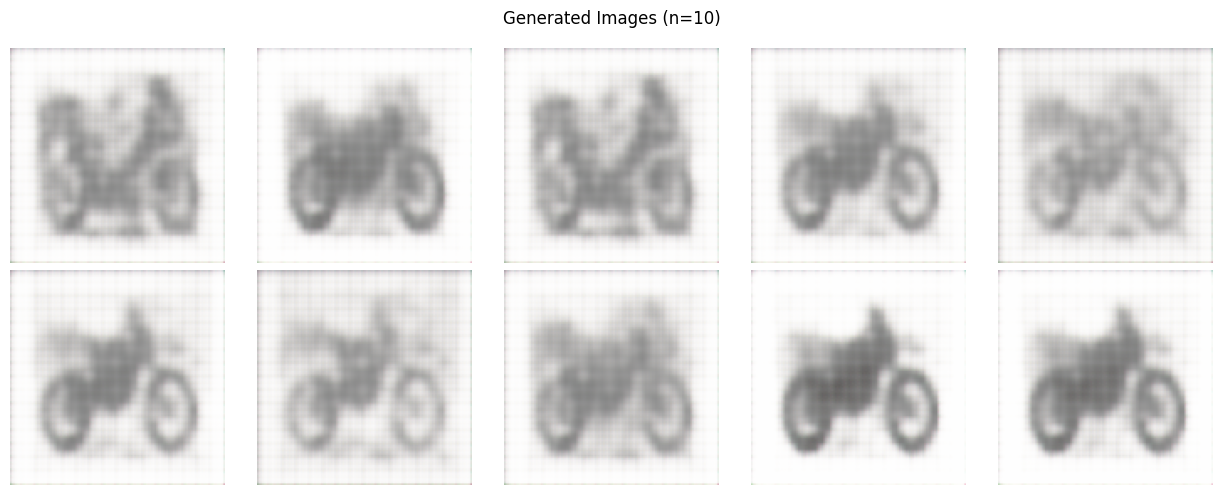

Generated images saved to ../reports/figures/generated_images_10.png


In [29]:
generated_images = generate_images(decoder, n_images=10)
plot_generated_images(generated_images, n_images=10)

In [36]:
models_path = "../models"

encoder.save(os.path.join(models_path, "encoder_lejdm_3_01.keras"))
decoder.save(os.path.join(models_path, "decoder_lejdm_3_01.keras"))

In [38]:
custom_objects = {
    'Sampling': Sampling,
}

encoder = keras.models.load_model(
    "../models/encoder_lejdm_3_01.keras",
    custom_objects=custom_objects
)

decoder = keras.models.load_model(
    "../models/decoder_lejdm_3_01.keras",
    custom_objects=custom_objects
)

In [40]:
var = VAE(encoder, decoder, beta=BETA)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))


── Test Set Evaluation ──
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - kl_loss: 11.5082 - reconstruction_loss: 1766.4728 - total_loss: 1777.9810
  total_loss:          1777.9810
  reconstruction_loss: 1766.4728
  kl_loss:             11.5082


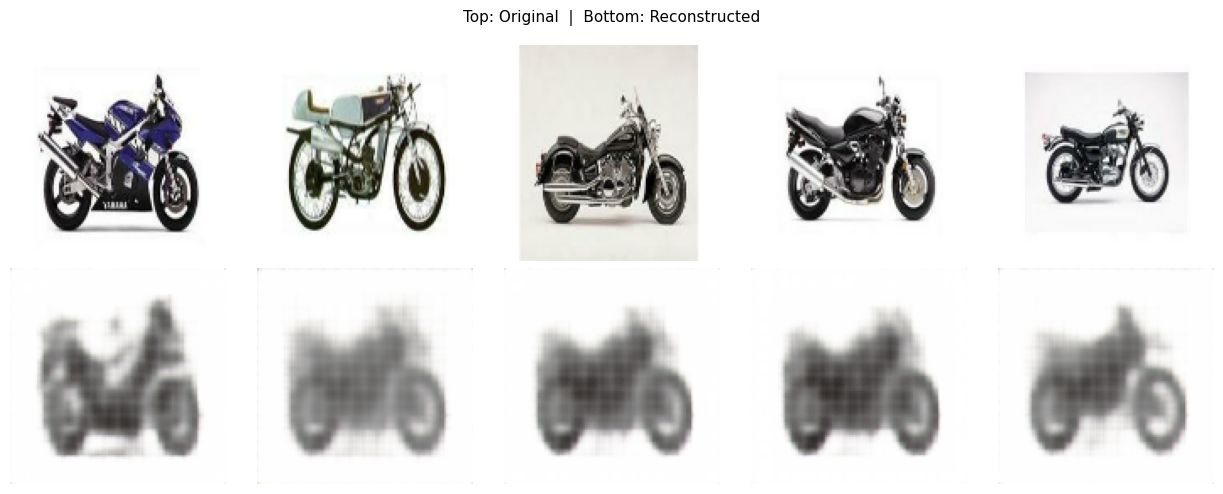

Reconstructions saved to ../reports/figures/test_reconstructions.png


In [41]:
evaluate_on_test(vae, decoder, x_test)

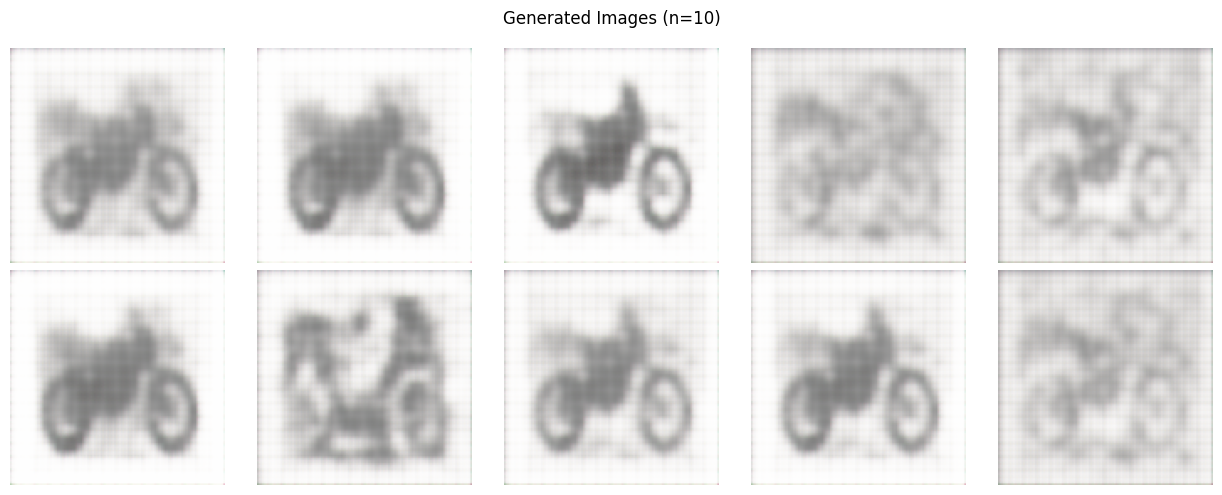

Generated images saved to ../reports/figures/generated_images_10.png


In [42]:
images = generate_images(decoder, n_images=10)
plot_generated_images(images, n_images=10)